In [1]:
import sys
import os
sys.path.append(os.path.abspath("../src"))


noise: tensor([[ 0.2291, -0.3055, -1.5777,  0.6979, -0.6230, -0.7981,  1.4269,  1.6009,
         -0.4257, -0.7564,  0.5599, -0.9863, -0.7966, -0.0247,  0.3243,  0.5658,
          0.5276, -1.5075,  1.1237,  0.7578, -0.3179, -1.1537,  0.4905,  1.0856,
          0.2318, -1.6477,  0.1945, -1.1951,  0.2915,  0.2935,  1.7603,  0.4730,
         -0.9521,  0.6425,  0.1766,  0.2198, -0.2659,  0.1263, -0.4573,  0.6064,
         -0.4392,  0.4913,  0.5078, -0.0740,  0.4196, -0.7854, -0.4548,  0.0073,
         -0.2890,  0.4108, -0.5173,  1.1818,  0.7086,  0.0981, -0.7990, -1.6478,
         -0.1206, -0.6267, -0.8439, -0.6183, -0.1255, -0.0493,  0.8383, -1.0019,
          0.6293, -1.8881,  0.6565,  1.8135, -1.5548, -0.8638, -0.1265,  0.5725,
          0.1506, -0.8425,  0.4235,  0.1104,  0.8008, -0.5051,  0.6917, -1.2036,
         -0.3480,  0.7057, -1.5271, -0.6907,  0.2623,  0.2013,  1.2611, -0.9101,
         -0.5762,  0.2753,  0.9575, -0.4979,  0.4797,  0.1172,  0.0389,  0.4117,
          0.0660, -0.

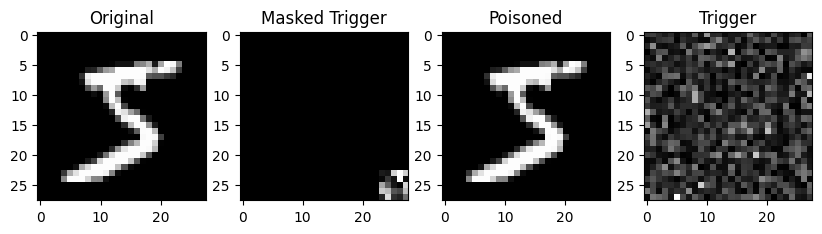

In [3]:
import torch
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from model.cban_generator import CBaNGenerator
from utils.trigger_utils import apply_trigger_masked, generate_mask

# Load model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
generator = CBaNGenerator().to(device)
generator.load_state_dict(torch.load("../models/cban_generator.pth", map_location=device))
generator.eval()

# Load sample
dataset = datasets.MNIST(root="../data", train=True, transform=transforms.ToTensor(), download=True)
image, label = dataset[0]

# Generate trigger
noise = torch.randn(1, 100).to(device)
target_label = torch.nn.functional.one_hot(torch.tensor([label]), num_classes=10).float().to(device)
print("noise:", noise)
print("target label:", target_label)
trigger = generator(noise, target_label)

# Apply trigger
image_tensor = image.unsqueeze(0).to(device)
mask = generate_mask(image_shape=(28, 28), patch_size=5).to(device)
masked_trigger = trigger * mask
poisoned = apply_trigger_masked(image_tensor.squeeze(), masked_trigger.squeeze(), mask)

# Visualize
fig, axes = plt.subplots(1, 4, figsize=(10, 4))
axes[0].imshow(image.squeeze(), cmap='gray'); axes[0].set_title("Original")
axes[1].imshow(masked_trigger.squeeze().detach().cpu(), cmap='gray'); axes[1].set_title("Masked Trigger")
axes[2].imshow(poisoned.squeeze().detach().cpu(), cmap='gray'); axes[2].set_title("Poisoned")
axes[3].imshow(trigger.squeeze().detach().cpu(), cmap='gray'); axes[3].set_title("Trigger")
plt.show()

In [5]:
from torch.utils.data import DataLoader
from data.poisoned_mnist import PoisonedMNISTDataset


poisoned_dataset = PoisonedMNISTDataset(
    root="../data",
    generator_ckpt="../models/cban_generator.pth",
    poison_rate=0.3,
    target_label=0
)

poisoned_loader = DataLoader(poisoned_dataset, batch_size=64, shuffle=True)
